In [1]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim 
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='.data/',train=True,transform=transform,download=True)
test_dataset = datasets.MNIST(root='.data/',train=False,transform=transform,download=True)

train_loader = DataLoader(dataset=train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(dataset=test_dataset,batch_size=64,shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

images,labels = next(iter(train_loader))
print(f"Image dimensions: {images.shape}")
print(f"labels : {labels[:10]}")





100.0%
100.0%
100.0%
100.0%

Number of training samples: 60000
Number of testing samples: 10000
Image dimensions: torch.Size([64, 1, 28, 28])
labels : tensor([2, 9, 8, 8, 7, 9, 2, 9, 7, 1])


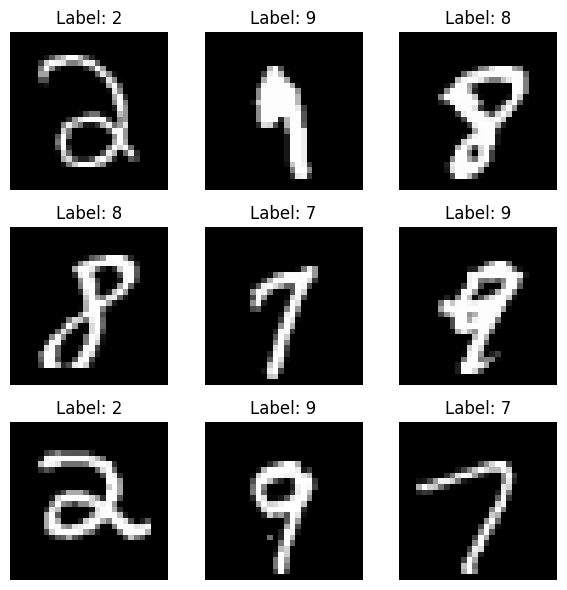

In [2]:
# visualize first 9 images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')  # squeeze removes channel dim
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),              # (64, 1, 28, 28) → (64, 784)
            nn.Linear(784, 256),       # 784 inputs → 256 neurons
            nn.ReLU(),
            nn.Dropout(0.2),           # randomly zero 20% of neurons
            nn.Linear(256, 128),       # 256 → 128
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)         # 128 → 10 classes (digits 0-9)
            # no sigmoid here — CrossEntropyLoss includes softmax internally
        )

    def forward(self, x):
        return self.network(x)

model = MNISTNet()
print(model)

# count parameters
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")

MNISTNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 235,146


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, criterion, optimizer):
    model.train()  # enable dropout
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in loader:
        output = model(images)
        loss   = criterion(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted   = output.argmax(dim=1)  # highest score = predicted class
        correct    += (predicted == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()  # disable dropout
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in loader:
            output    = model(images)
            loss      = criterion(output, labels)
            total_loss += loss.item()
            predicted   = output.argmax(dim=1)
            correct    += (predicted == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

# train for 10 epochs
train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader,
                                        criterion, optimizer)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:2d} → "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

Epoch  1 → Train Loss: 0.2797 Acc: 0.9144 | Test Loss: 0.1176 Acc: 0.9634
Epoch  2 → Train Loss: 0.1308 Acc: 0.9598 | Test Loss: 0.0920 Acc: 0.9713
Epoch  3 → Train Loss: 0.0986 Acc: 0.9695 | Test Loss: 0.0762 Acc: 0.9781
Epoch  4 → Train Loss: 0.0831 Acc: 0.9738 | Test Loss: 0.0937 Acc: 0.9720
Epoch  5 → Train Loss: 0.0724 Acc: 0.9773 | Test Loss: 0.0678 Acc: 0.9797
Epoch  6 → Train Loss: 0.0643 Acc: 0.9799 | Test Loss: 0.0690 Acc: 0.9798
Epoch  7 → Train Loss: 0.0605 Acc: 0.9809 | Test Loss: 0.0712 Acc: 0.9806
Epoch  8 → Train Loss: 0.0543 Acc: 0.9826 | Test Loss: 0.0766 Acc: 0.9768
Epoch  9 → Train Loss: 0.0499 Acc: 0.9836 | Test Loss: 0.0698 Acc: 0.9798
Epoch 10 → Train Loss: 0.0470 Acc: 0.9848 | Test Loss: 0.0662 Acc: 0.9813


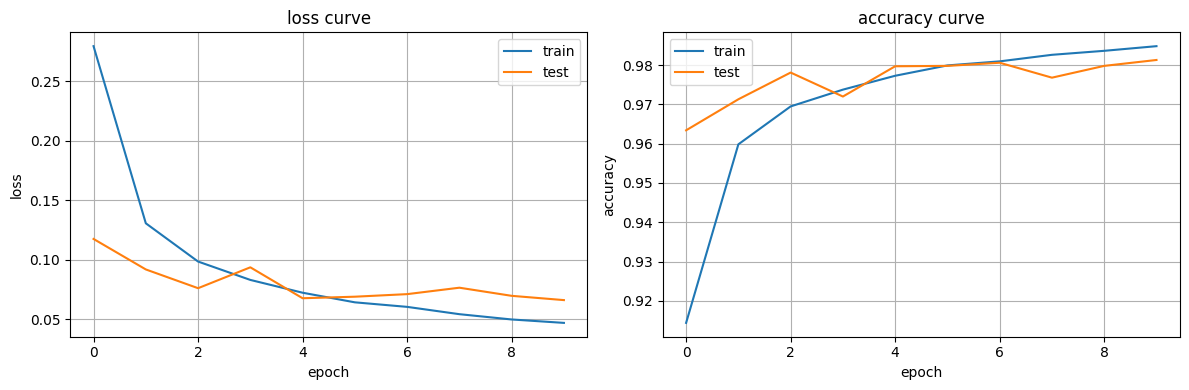

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='train')
axes[0].plot(test_losses,  label='test')
axes[0].set_title('loss curve')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='train')
axes[1].plot(test_accs,  label='test')
axes[1].set_title('accuracy curve')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Total wrong: 187 out of 10,000


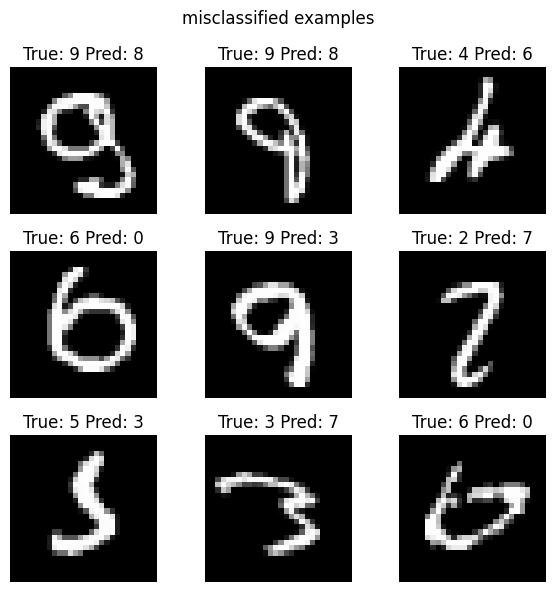

In [6]:
model.eval()
wrong_images  = []
wrong_labels  = []
wrong_preds   = []

with torch.no_grad():
    for images, labels in test_loader:
        output    = model(images)
        predicted = output.argmax(dim=1)
        mask      = predicted != labels  # wrong predictions only

        wrong_images.append(images[mask])
        wrong_labels.append(labels[mask])
        wrong_preds.append(predicted[mask])

wrong_images = torch.cat(wrong_images)
wrong_labels = torch.cat(wrong_labels)
wrong_preds  = torch.cat(wrong_preds)

print(f"Total wrong: {len(wrong_images)} out of 10,000")

# plot first 9 wrong predictions
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {wrong_labels[i]} Pred: {wrong_preds[i]}")
    ax.axis('off')
plt.suptitle('misclassified examples')
plt.tight_layout()
plt.show()